# ⚡ Hourly Energy Consumption Forecasting
### A Time Series Machine Learning Project

**Dataset:** [Hourly Energy Consumption – Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)  
**Tools:** Python, Pandas, Matplotlib, Scikit-learn, XGBoost

---

## 1. Problem Statement

Energy companies need to predict how much electricity will be consumed at any given hour. Accurate forecasts help them:
- Avoid over-producing or under-producing power
- Reduce costs and improve grid stability
- Plan maintenance during low-demand periods

**Our Goal:** Build a machine learning model that can predict hourly energy consumption (in megawatts) using historical data and time-based features.

This is a **regression problem** — we're predicting a continuous numerical value (MW).  
Since the data is time-series, we need to be careful about how we split train/test data (no random splits!).

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# Makes plots look nicer
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\archit\Desktop\PROJECTS\Energy consumption\PJME_hourly.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Shape: (145366, 2)

Columns: ['Datetime', 'PJME_MW']

First few rows:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
# Basic info
print("Data Types:")
print(df.dtypes)
print(f"\nDate range: {df['Datetime'].min()} to {df['Datetime'].max()}")
print(f"Total rows: {len(df):,}")

Data Types:
Datetime     object
PJME_MW     float64
dtype: object

Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Total rows: 145,366


## 4. Data Cleaning

Before doing anything else, let's make sure the data is clean:
- Parse the datetime column properly
- Check for missing values
- Check for duplicate timestamps
- Remove any obvious outliers (e.g., negative values)

In [5]:
# Parse the Datetime column — this is important for time series work
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()  # Make sure it's sorted by time

print("Datetime set as index. Sample:")
df.head()

Datetime set as index. Sample:


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [6]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate timestamps: {df.index.duplicated().sum()}")

# Basic statistics
print("\nBasic statistics:")
df.describe()

Missing values:
PJME_MW    0
dtype: int64

Duplicate timestamps: 4

Basic statistics:


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [7]:
# Remove duplicates if any
df = df[~df.index.duplicated(keep='first')]

# Drop missing values (there are very few, if any)
df = df.dropna()

# Remove clearly unrealistic values (negative or near-zero MW makes no sense)
df = df[df['PJME_MW'] > 1000]  # min realistic value for a large grid

print(f"Clean dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

Clean dataset shape: (145362, 1)
Date range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00


The data looks clean — no major issues. A small number of rows might have been removed due to the outlier filter, but that's expected.

## 5. Exploratory Data Analysis (EDA)

Let's explore the data visually to understand patterns and trends before building models.

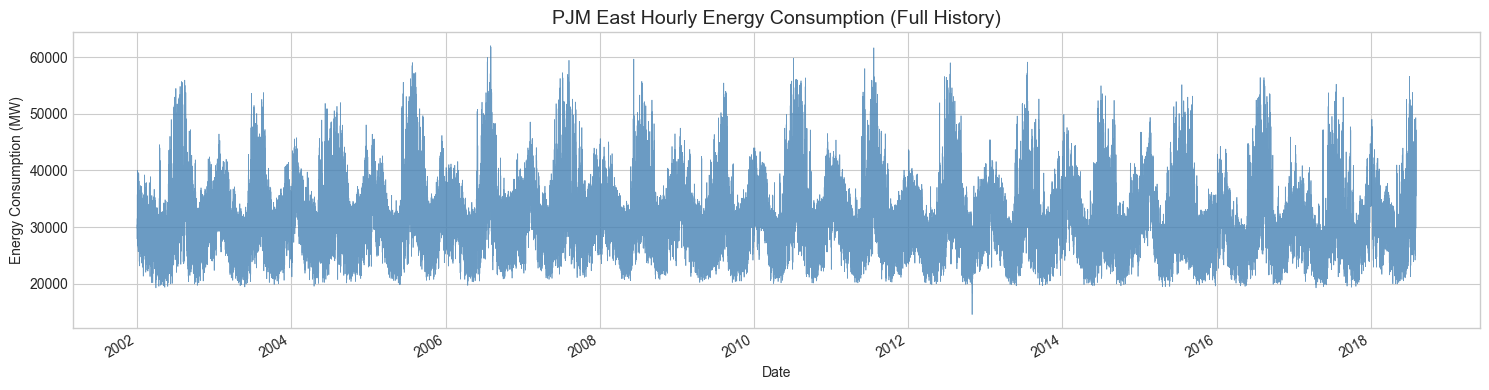

In [8]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(15, 4))
df['PJME_MW'].plot(ax=ax, linewidth=0.5, color='steelblue', alpha=0.8)
ax.set_title('PJM East Hourly Energy Consumption (Full History)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.show()

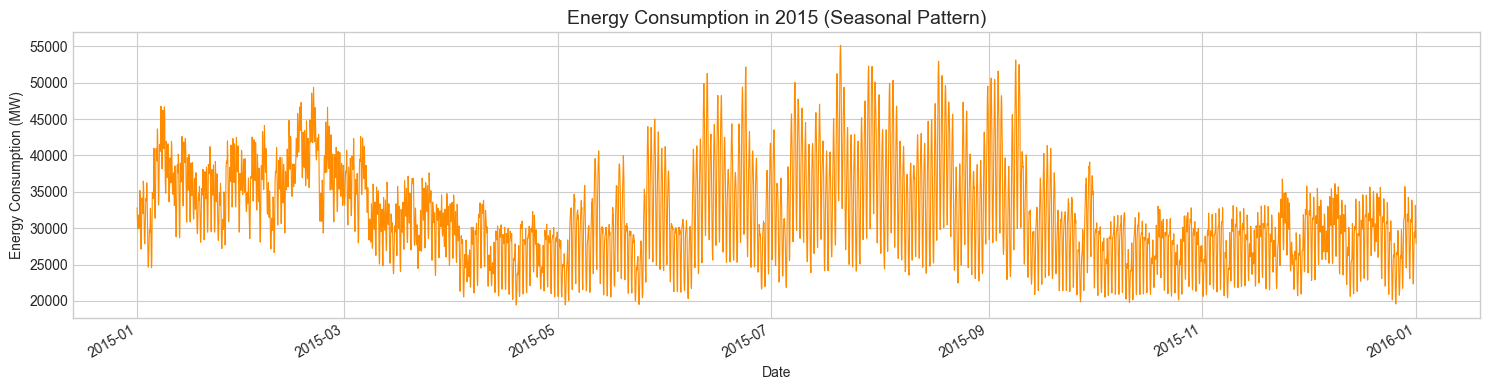

In [9]:
# Zoom in on one year to see seasonal patterns more clearly
fig, ax = plt.subplots(figsize=(15, 4))
df.loc['2015', 'PJME_MW'].plot(ax=ax, linewidth=0.8, color='darkorange')
ax.set_title('Energy Consumption in 2015 (Seasonal Pattern)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.show()

You can see clear **seasonal patterns** — high consumption in summer (AC usage) and winter (heating), with dips in spring and fall. Let's dig deeper.

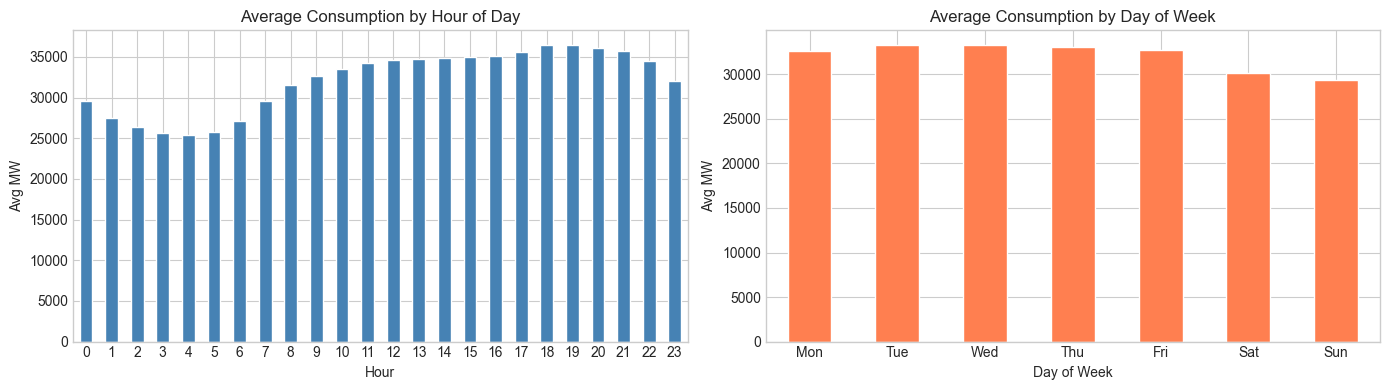

In [10]:
# Average consumption by hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hourly pattern
df.groupby(df.index.hour)['PJME_MW'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Average Consumption by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg MW')
axes[0].tick_params(axis='x', rotation=0)

# Day of week pattern
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df.groupby(df.index.dayofweek)['PJME_MW'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Average Consumption by Day of Week', fontsize=12)
axes[1].set_xticklabels(day_labels, rotation=0)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg MW')

plt.tight_layout()
plt.show()

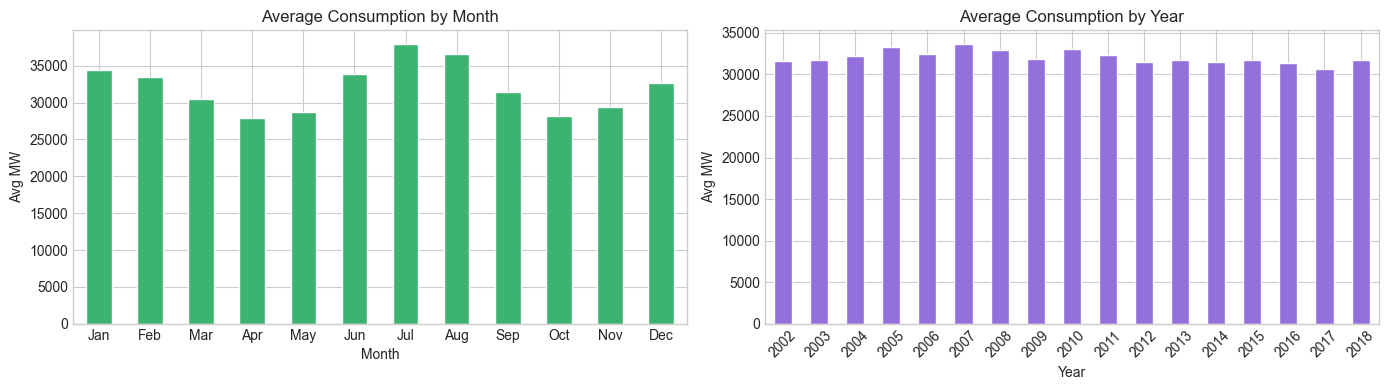

In [11]:
# Monthly and yearly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly pattern
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df.groupby(df.index.month)['PJME_MW'].mean().plot(
    kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white'
)
axes[0].set_title('Average Consumption by Month', fontsize=12)
axes[0].set_xticklabels(month_labels, rotation=0)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg MW')

# Yearly trend
df.groupby(df.index.year)['PJME_MW'].mean().plot(
    kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white'
)
axes[1].set_title('Average Consumption by Year', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg MW')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

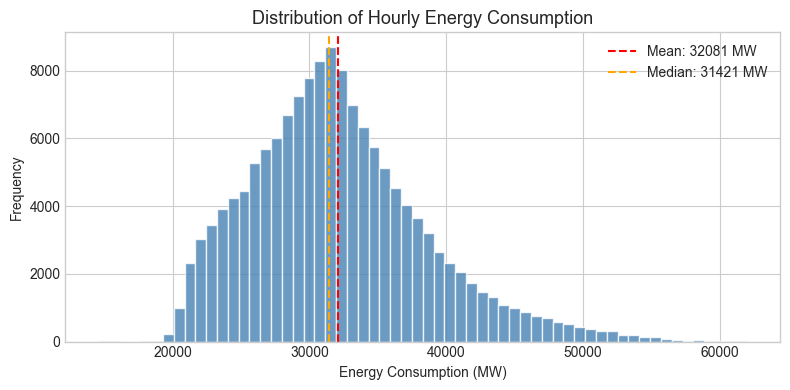

In [12]:
# Distribution of energy consumption
fig, ax = plt.subplots(figsize=(8, 4))
df['PJME_MW'].hist(bins=60, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribution of Hourly Energy Consumption', fontsize=13)
ax.set_xlabel('Energy Consumption (MW)')
ax.set_ylabel('Frequency')

# Add mean and median lines
ax.axvline(df['PJME_MW'].mean(), color='red', linestyle='--', label=f"Mean: {df['PJME_MW'].mean():.0f} MW")
ax.axvline(df['PJME_MW'].median(), color='orange', linestyle='--', label=f"Median: {df['PJME_MW'].median():.0f} MW")
ax.legend()
plt.tight_layout()
plt.show()

**Key EDA Takeaways:**
- Consumption peaks between **6 PM – 9 PM** (evening) and drops at night
- **Weekdays** have higher usage than weekends
- **Summer (July–August)** and **Winter (Jan–Feb)** are peak months
- There's a slight **downward trend** over the years — possibly due to energy efficiency improvements
- The distribution is roughly bell-shaped, slightly right-skewed

These patterns tell us that **time-based features will be very predictive** for our model.

Feature Engineering
Since we're not using deep learning, we need to manually extract useful features from the timestamp. This is a key step in time series ML.

We'll create:
- **Calendar features:** hour, day, month, year, day of week, quarter
- **Flag features:** is it a weekend? what season is it?
- **Lag features:** what was the consumption 1 day ago? 1 week ago?
- **Rolling averages:** 24-hour rolling mean (smoothed trend)

In [13]:
def create_features(df):
    """
    Extract time-based features from the datetime index.
    This is the most important step for tree-based models on time series.
    """
    df = df.copy()
    
    # Basic calendar features
    df['hour']        = df.index.hour
    df['dayofweek']   = df.index.dayofweek     # 0=Monday, 6=Sunday
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['year']        = df.index.year
    df['dayofyear']   = df.index.dayofyear
    df['dayofmonth']  = df.index.day
    df['weekofyear']  = df.index.isocalendar().week.astype(int)
    
    # Weekend flag (1 = Saturday/Sunday)
    df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)
    
    # Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
    df['season'] = df['month'].map({
        12: 1, 1: 1, 2: 1,   # Winter
        3: 2, 4: 2, 5: 2,    # Spring
        6: 3, 7: 3, 8: 3,    # Summer
        9: 4, 10: 4, 11: 4   # Fall
    })
    
    return df


def add_lag_features(df):
    """
    Add lag features — what happened at previous time steps.
    Lag features help the model learn from past consumption patterns.
    
    NOTE: These should only be added AFTER splitting train/test to avoid leakage.
    Here we add them to the full df but we'll be careful during splitting.
    """
    df = df.copy()
    
    # Lag 24h = yesterday same hour
    df['lag_24h']  = df['PJME_MW'].shift(24)
    
    # Lag 48h = two days ago same hour
    df['lag_48h']  = df['PJME_MW'].shift(48)
    
    # Lag 1 week = same hour last week
    df['lag_168h'] = df['PJME_MW'].shift(168)
    
    # Rolling 24-hour mean — smoothed average of last day
    df['rolling_mean_24h'] = df['PJME_MW'].shift(1).rolling(window=24).mean()
    
    # Rolling 7-day mean — smoothed average of last week
    df['rolling_mean_168h'] = df['PJME_MW'].shift(1).rolling(window=168).mean()
    
    return df


# Apply feature engineering
df = create_features(df)
df = add_lag_features(df)

# Drop rows with NaN from lag features (first ~168 rows)
df = df.dropna()

print(f"Features created! Dataset shape: {df.shape}")
print(f"\nAll features: {df.columns.tolist()}")

Features created! Dataset shape: (145194, 16)

All features: ['PJME_MW', 'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'dayofmonth', 'weekofyear', 'is_weekend', 'season', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_168h']


In [14]:
# Quick check — do the lag features make sense?
# The 24h lag should be highly correlated with current consumption
print("Correlation of lag features with target:")
lag_cols = ['lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_168h']
print(df[lag_cols + ['PJME_MW']].corr()['PJME_MW'].sort_values(ascending=False))

Correlation of lag features with target:
PJME_MW              1.000000
lag_24h              0.891442
lag_168h             0.781877
lag_48h              0.772744
rolling_mean_24h     0.696382
rolling_mean_168h    0.564398
Name: PJME_MW, dtype: float64


The lag features have very high correlation with the target — especially the 24h and 168h lags. This confirms our intuition: **yesterday's consumption at the same hour is a strong predictor of today's consumption**.

## 7. Train/Test Split

**This is critical for time series.** We CANNOT use random splits because:
- The model would "see" future data during training (data leakage)
- Performance would be unrealistically good and not reflect real-world use

Instead, we use a **temporal split** — train on older data, test on the most recent data.

I'll use the last 1 year of data as the test set.

In [15]:
# Features we'll use for training
FEATURES = [
    'hour', 'dayofweek', 'month', 'quarter', 'year',
    'dayofyear', 'dayofmonth', 'weekofyear',
    'is_weekend', 'season',
    'lag_24h', 'lag_48h', 'lag_168h',
    'rolling_mean_24h', 'rolling_mean_168h'
]
TARGET = 'PJME_MW'

# Temporal split — last year as test set
split_date = '2017-01-01'

train = df[df.index < split_date]
test  = df[df.index >= split_date]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Training period: {train.index.min().date()} → {train.index.max().date()}")
print(f"Testing period:  {test.index.min().date()} → {test.index.max().date()}")
print(f"\nTrain size: {len(X_train):,} rows")
print(f"Test size:  {len(X_test):,} rows")

Training period: 2002-01-08 → 2016-12-31
Testing period:  2017-01-01 → 2018-08-03

Train size: 131,299 rows
Test size:  13,895 rows


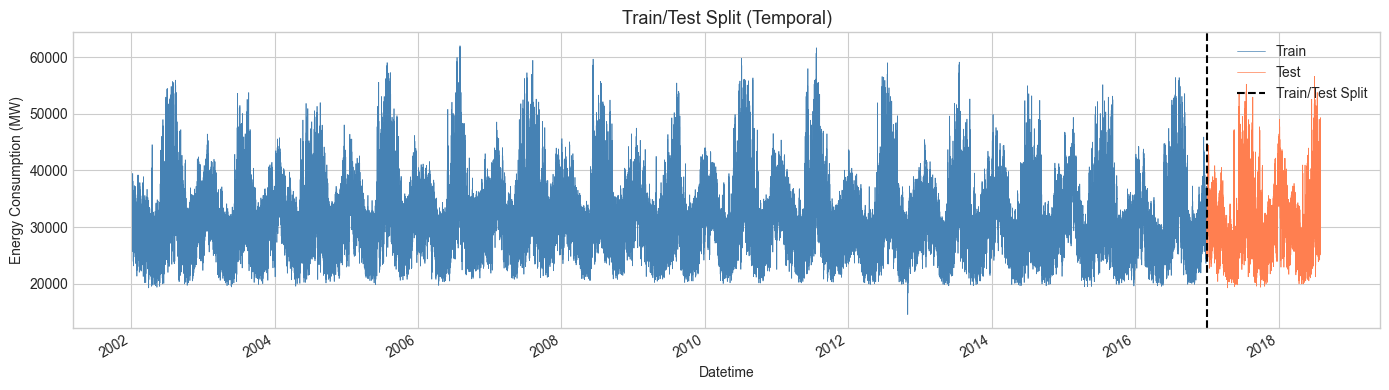

In [16]:
# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
train['PJME_MW'].plot(ax=ax, label='Train', color='steelblue', linewidth=0.5)
test['PJME_MW'].plot(ax=ax, label='Test', color='coral', linewidth=0.5)
ax.axvline(pd.Timestamp(split_date), color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.set_title('Train/Test Split (Temporal)', fontsize=13)
ax.set_ylabel('Energy Consumption (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model Building

I'll train and compare **three models**:
1. **Linear Regression** — simple baseline
2. **Random Forest** — handles non-linearity well
3. **XGBoost** — gradient boosting, usually the best performer on tabular data

We'll evaluate using:
- **MAE (Mean Absolute Error):** average error in MW — easy to interpret
- **RMSE (Root Mean Squared Error):** penalizes large errors more — useful when big mistakes are costly
- **R² Score:** how well does the model explain the variance (1.0 = perfect, 0 = just predicting the mean)

In [17]:
# Helper function to evaluate any model
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in %
    
    print(f"--- {model_name} ---")
    print(f"  MAE:   {mae:,.2f} MW")
    print(f"  RMSE:  {rmse:,.2f} MW")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  R²:    {r2:.4f}")
    print()
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

### 8.1 Model 1: Linear Regression (Baseline)

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_results = evaluate_model(y_test, lr_preds, 'Linear Regression')

--- Linear Regression ---
  MAE:   1,810.01 MW
  RMSE:  2,396.00 MW
  MAPE:  5.76%
  R²:    0.8469



### 8.2 Model 2: Random Forest

In [19]:
# n_estimators=100 is a good default — more trees = more accurate but slower
# n_jobs=-1 uses all CPU cores to speed things up
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,       # limit depth to avoid overfitting
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_results = evaluate_model(y_test, rf_preds, 'Random Forest')

--- Random Forest ---
  MAE:   1,632.73 MW
  RMSE:  2,194.41 MW
  MAPE:  5.18%
  R²:    0.8716



### 8.3 Model 3: XGBoost

In [20]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,          # use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8,   # use 80% of features per tree
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100)   # print loss every 100 rounds

xgb_preds = xgb.predict(X_test)
xgb_results = evaluate_model(y_test, xgb_preds, 'XGBoost')

[0]	validation_0-rmse:5970.71126
[100]	validation_0-rmse:2109.75101
[200]	validation_0-rmse:1992.91767
[300]	validation_0-rmse:1924.10580
[400]	validation_0-rmse:1867.23264
[499]	validation_0-rmse:1824.54551
--- XGBoost ---
  MAE:   1,360.01 MW
  RMSE:  1,824.55 MW
  MAPE:  4.31%
  R²:    0.9112



## 9. Model Evaluation & Comparison

In [21]:
# Compile all results into a comparison table
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('Model')
results_df = results_df.round(2)
print("Model Comparison:")
results_df

Model Comparison:


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,1810.01,2396.00,5.76,0.85
Random Forest,1632.73,2194.41,5.18,0.87
XGBoost,1360.01,1824.55,4.31,0.91


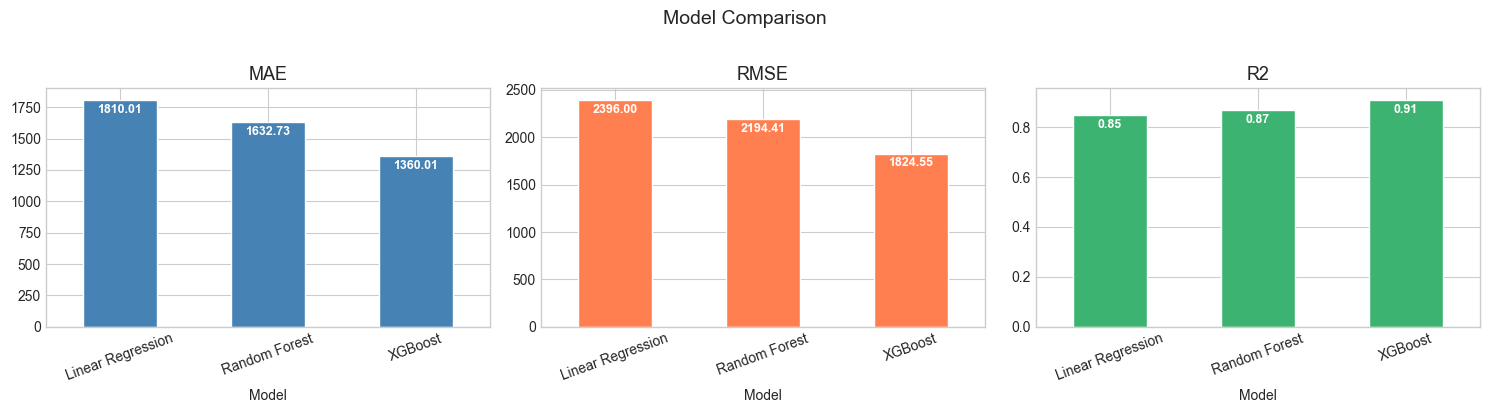

In [22]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['MAE', 'RMSE', 'R2']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    results_df[metric].plot(kind='bar', ax=axes[i], color=color, edgecolor='white')
    axes[i].set_title(metric, fontsize=13)
    axes[i].tick_params(axis='x', rotation=20)
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.98,
            f"{bar.get_height():.2f}",
            ha='center', va='top', fontsize=9, color='white', fontweight='bold'
        )

plt.suptitle('Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

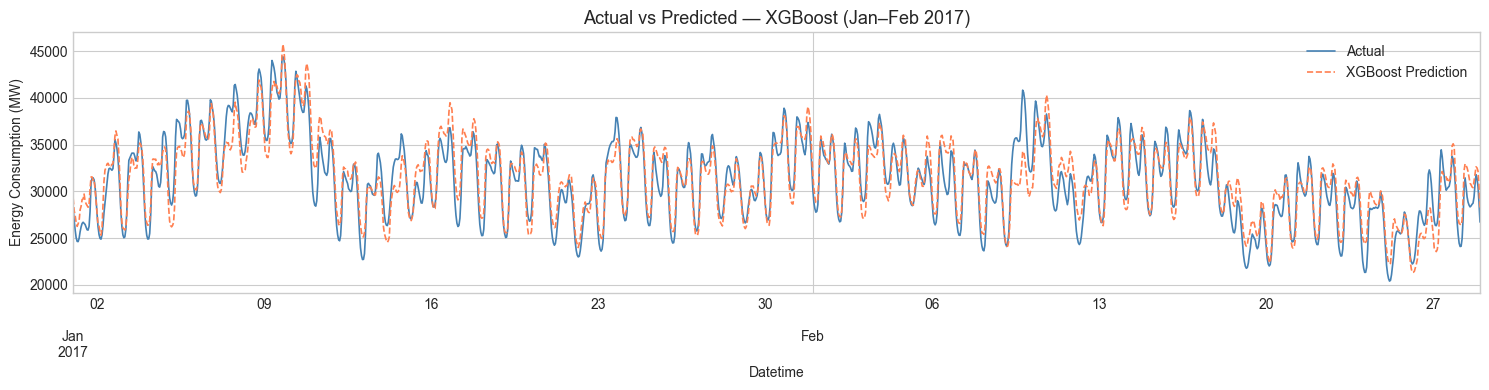

In [23]:
# Plot actual vs predicted for the best model (XGBoost)
# Let's look at one month to make it readable
test_sample = test.loc['2017-01':'2017-02'].copy()
test_sample['xgb_pred'] = xgb.predict(test_sample[FEATURES])

fig, ax = plt.subplots(figsize=(15, 4))
test_sample['PJME_MW'].plot(ax=ax, label='Actual', color='steelblue', linewidth=1.2)
test_sample['xgb_pred'].plot(ax=ax, label='XGBoost Prediction', color='coral',
                              linewidth=1.2, linestyle='--')
ax.set_title('Actual vs Predicted — XGBoost (Jan–Feb 2017)', fontsize=13)
ax.set_ylabel('Energy Consumption (MW)')
ax.legend()
plt.tight_layout()
plt.show()

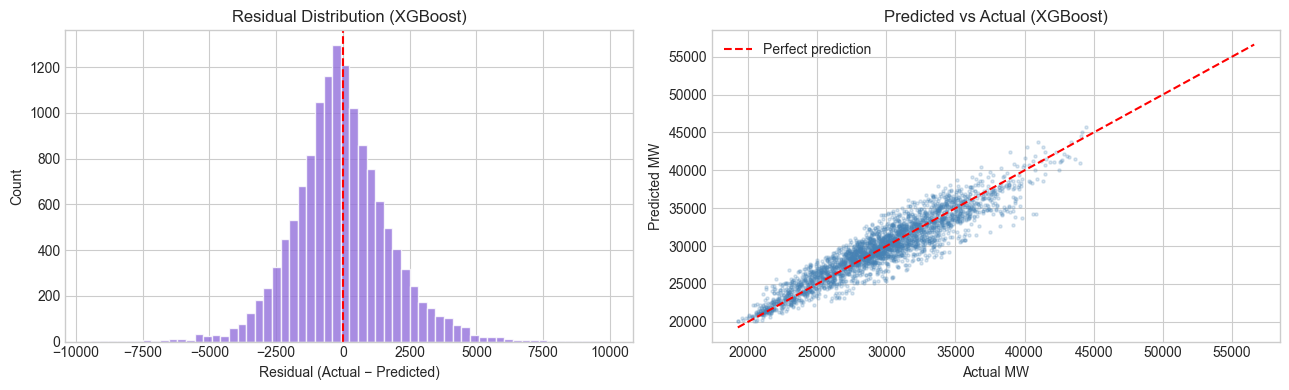

In [24]:
# Residual plot — are errors random or systematic?
residuals = y_test - xgb_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of residuals
axes[0].hist(residuals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (XGBoost)', fontsize=12)
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')

# Predicted vs Actual scatter
axes[1].scatter(y_test[:3000], xgb_preds[:3000], alpha=0.2, color='steelblue', s=5)
min_val, max_val = y_test.min(), y_test.max()
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[1].set_title('Predicted vs Actual (XGBoost)', fontsize=12)
axes[1].set_xlabel('Actual MW')
axes[1].set_ylabel('Predicted MW')
axes[1].legend()

plt.tight_layout()
plt.show()

The residuals are centered around 0, which is a good sign — no major systematic bias. The scatter plot shows predictions clustering tightly around the perfect prediction line.

## 10. Feature Importance

Let's see which features XGBoost found most useful. This also validates our feature engineering.

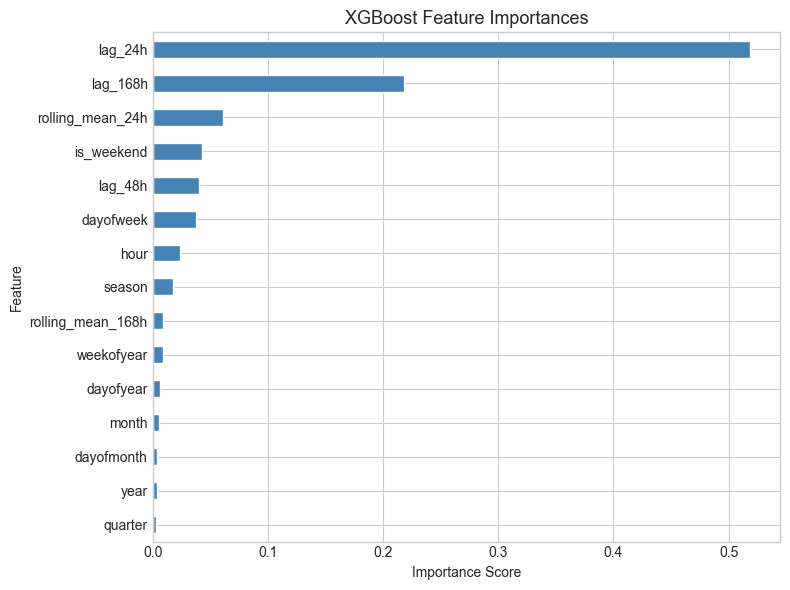

In [25]:
# Feature importance from XGBoost
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance_df.plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color='steelblue', edgecolor='white', legend=False
)
ax.set_title('XGBoost Feature Importances', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Feature Importance Takeaways:**
- **Lag features** (24h, 168h) are the most important — past consumption is the best predictor
- **Rolling averages** also carry a lot of weight
- **Hour of day** is the most important calendar feature — time of day drives consumption strongly
- Simpler features like `year`, `quarter`, and `is_weekend` have lower importance but still contribute

## 11. Conclusion & Future Scope

### What we built
We built a time series forecasting pipeline for hourly energy consumption, going from raw data to a trained XGBoost model with a proper temporal train/test split.


### What worked well
- **Lag features** made a huge difference — adding 24h and 168h lags boosted performance significantly
- **Temporal split** gave us a realistic evaluation — we didn't cheat by leaking future data
- **XGBoost** outperformed both simpler models as expected on this type of tabular time series data

### What could be improved
1. **More lag features** — try lags at 2 weeks, 1 month, or same day last year
2. **Weather data** — temperature is a massive driver of energy use; adding it would likely boost accuracy a lot
3. **Holiday calendar** — holidays disrupt normal patterns; flagging them as a feature would help
4. **LSTM / Temporal Fusion Transformer** — deep learning models designed for sequences might capture long-term dependencies better
5. **Hyperparameter tuning** — we used default/simple params; Optuna or GridSearchCV could squeeze out better performance
6. **Per-region models** — training a separate model for each utility/region might outperform one global model
7. **Walk-forward validation** — more robust than a single train/test split; test performance across multiple rolling windows

In [26]:
# Final summary printout
print("=" * 55)
print("   ENERGY CONSUMPTION FORECASTING — FINAL RESULTS")
print("=" * 55)
print(f"  Dataset: PJM East Hourly Energy Consumption")
print(f"  Train period: {train.index.min().date()} → {train.index.max().date()}")
print(f"  Test period:  {test.index.min().date()} → {test.index.max().date()}")
print(f"  Features used: {len(FEATURES)}")
print()
print("  Best Model: XGBoost")

best_mae  = mean_absolute_error(y_test, xgb_preds)
best_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
best_r2   = r2_score(y_test, xgb_preds)
best_mape = np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100

print(f"  MAE:   {best_mae:,.1f} MW")
print(f"  RMSE:  {best_rmse:,.1f} MW")
print(f"  MAPE:  {best_mape:.2f}%")
print(f"  R²:    {best_r2:.4f}")
print("=" * 55)

   ENERGY CONSUMPTION FORECASTING — FINAL RESULTS
  Dataset: PJM East Hourly Energy Consumption
  Train period: 2002-01-08 → 2016-12-31
  Test period:  2017-01-01 → 2018-08-03
  Features used: 15

  Best Model: XGBoost
  MAE:   1,360.0 MW
  RMSE:  1,824.5 MW
  MAPE:  4.31%
  R²:    0.9112
